In [ ]:
import json
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

# Change these bb
SUMMARY_PATH = Path("/home/akapociu/ift/interactiondynamics/results/test/summary.jsonl")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
def parse_run_name(run_name: str) -> dict:
    """
    Pull aggregator/update out of run strings like:
    ..._agg=ift|update=ift_update|do=0.0|...
    """
    out = {}

    m_agg = re.search(r"agg=([^|]+)", run_name)
    m_upd = re.search(r"update=([^|]+)", run_name)

    out["aggregator"] = m_agg.group(1) if m_agg else None
    out["update"] = m_upd.group(1) if m_upd else None

    return out


def get_nested_metric(row: dict, split: str, metric: str, snapshot: str = "best_snapshot"):
    """
    Example:
      get_nested_metric(row, "val", "roc_auc")
      -> row["best_snapshot"]["val"]["roc_auc"]
    """
    try:
        return row[snapshot][split][metric]
    except Exception:
        return np.nan


rows = []
with open(SUMMARY_PATH, "r") as f:
    for line in f:
        if not line.strip():
            continue

        raw = json.loads(line)
        parsed = parse_run_name(raw.get("run", ""))

        row = {
            "dataset": raw.get("dataset"),
            "run": raw.get("run"),
            "seed": raw.get("seed"),
            "best_epoch": raw.get("best_epoch"),
            "selection_metric": raw.get("selection_metric"),
            "aggregator": parsed["aggregator"],
            "update": parsed["update"],

            # Best-epoch metrics
            "val_roc_auc": get_nested_metric(raw, "val", "roc_auc"),
            "test_roc_auc": get_nested_metric(raw, "test", "roc_auc"),
            "val_pr_auc": get_nested_metric(raw, "val", "pr_auc"),
            "test_pr_auc": get_nested_metric(raw, "test", "pr_auc"),

            # Useful extras
            "val_norm_pr_auc": get_nested_metric(raw, "val", "norm_pr_auc"),
            "test_norm_pr_auc": get_nested_metric(raw, "test", "norm_pr_auc"),
            "val_edge_density": get_nested_metric(raw, "val", "edge_density"),
            "test_edge_density": get_nested_metric(raw, "test", "edge_density"),
            "val_pred_density": get_nested_metric(raw, "val", "pred_edge_density"),
            "test_pred_density": get_nested_metric(raw, "test", "pred_edge_density"),
        }

        rows.append(row)

summary_df = pd.DataFrame(rows)

summary_df.head()

,dataset,run,seed,best_epoch,selection_metric,aggregator,update,val_roc_auc,test_roc_auc,val_pr_auc,test_pr_auc,val_norm_pr_auc,test_norm_pr_auc,val_edge_density,test_edge_density,val_pred_density,test_pred_density
0,charged_particles__distance_threshold__2p23916...,charged_particles__distance_threshold__2p23916...,0,3,roc_auc,ift,ift_update,0.61483,0.59667,0.307833,0.280697,1.404265e-01,1.143025e-01,0.194649,0.188022,0.0,0.0
1,charged_particles__distance_threshold__2p23916...,charged_particles__distance_threshold__2p23916...,0,1,roc_auc,ift,tgn_gru,0.50000,0.50000,0.194649,0.188022,-1.504325e-08,-1.353854e-08,0.194649,0.188022,0.0,0.0
2,charged_particles__distance_threshold__2p23916...,charged_particles__distance_threshold__2p23916...,0,1,roc_auc,ift,lnn,0.50000,0.50000,0.194649,0.188022,-1.504325e-08,-1.353854e-08,0.194649,0.188022,0.0,0.0
3,charged_particles__distance_threshold__2p23916...,charged_particles__distance_threshold__2p23916...,0,2,roc_auc,ift,hopfield_update,0.50000,0.50000,0.194649,0.188022,-1.504325e-08,-1.353854e-08,0.194649,0.188022,0.0,0.0
4,charged_particles__distance_threshold__2p23916...,charged_particles__distance_threshold__2p23916...,0,1,roc_auc,ift,hnn,0.50000,0.50000,0.194649,0.188022,-1.504325e-08,-1.353854e-08,0.194649,0.188022,0.0,0.0


In [ ]:
AGG_ORDER = ["sum", "ift", "settransformer", "hopfield", "deepsets"]
UPD_ORDER = ["tgn_gru", "ift_update", "hnn", "lnn", "hopfield_update"]

AGG_PRETTY = {
    "sum": "Sum",
    "ift": "IFT",
    "settransformer": "SetTransformer",
    "hopfield": "Hopfield",
    "deepsets": "DeepSets",
}

UPD_PRETTY = {
    "tgn_gru": "TGN-GRU",
    "ift_update": "IFT Update",
    "hnn": "HNN",
    "lnn": "LNN",
    "hopfield_update": "Hopfield Update",
}

def pretty_agg(x):
    return AGG_PRETTY.get(str(x), str(x))

def pretty_upd(x):
    return UPD_PRETTY.get(str(x), str(x))

In [ ]:
# Use only orders that actually appear, but keep preferred ordering.
present_aggs = set(summary_df["aggregator"].dropna())
present_upds = set(summary_df["update"].dropna())

AGG_ORDER_USED = [a for a in AGG_ORDER if a in present_aggs]
UPD_ORDER_USED = [u for u in UPD_ORDER if u in present_upds]

# Add any surprise values at the end.
AGG_ORDER_USED += sorted(present_aggs - set(AGG_ORDER_USED))
UPD_ORDER_USED += sorted(present_upds - set(UPD_ORDER_USED))

DATASET_ORDER = sorted(summary_df["dataset"].dropna().unique())

print("Datasets:", DATASET_ORDER)
print("Aggregators:", AGG_ORDER_USED)
print("Updates:", UPD_ORDER_USED)

Datasets: ['charged_particles__distance_threshold__2p23916__splits-all', 'charged_particles__distance_threshold__4p582872__splits-all', 'charged_particles__distance_threshold__6p782091__splits-all']
Aggregators: ['sum', 'ift', 'settransformer', 'hopfield', 'deepsets']
Updates: ['tgn_gru', 'ift_update', 'hnn', 'lnn', 'hopfield_update']


In [ ]:
def aggregate_metric_with_density(
    df: pd.DataFrame,
    metric_col: str,
    density_col: str,
) -> pd.DataFrame:
    """
    One row per dataset/aggregator/update with mean/std across seeds
    for the metric, plus avg edge density.
    """
    grouped = (
        df.groupby(["dataset", "aggregator", "update"], dropna=False)
          .agg(
              avg_metric=(metric_col, "mean"),
              std_metric=(metric_col, "std"),
              n_seeds=(metric_col, "count"),
              avg_density=(density_col, "mean"),
              std_density=(density_col, "std"),
          )
          .reset_index()
    )
    return grouped

In [ ]:
def plot_grouped_metric_with_density(
    df: pd.DataFrame,
    metric_col: str,
    density_col: str,
    metric_label: str,
    density_label: str,
    plot_filename: str,
    title_prefix: str = "Whole-bin Edge Prediction",
    ylim=(0, 1.05),
):
    agg_df = aggregate_metric_with_density(df, metric_col, density_col)

    full_index = pd.MultiIndex.from_product(
        [AGG_ORDER_USED, UPD_ORDER_USED],
        names=["aggregator", "update"],
    )
    full_df = pd.DataFrame(index=full_index).reset_index()

    n_panels = len(DATASET_ORDER)
    ncols = min(2, n_panels)
    nrows = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(12 * ncols, 6.5 * nrows),
        sharey=False,
    )

    if n_panels == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    for ax in axes[n_panels:]:
        ax.axis("off")

    labels_abcd = [f"({chr(ord('a') + i)})" for i in range(n_panels)]

    n_upds = len(UPD_ORDER_USED)
    n_aggs = len(AGG_ORDER_USED)

    boundaries = [
        i * n_upds - 0.5
        for i in range(1, n_aggs)
    ]

    group_centers = [
        i * n_upds + (n_upds - 1) / 2
        for i in range(n_aggs)
    ]

    for ax, ds, panel_label in zip(axes, DATASET_ORDER, labels_abcd):
        focus_df = agg_df[agg_df["dataset"] == ds].copy()

        df_full = full_df.merge(
            focus_df,
            on=["aggregator", "update"],
            how="left",
        )

        df_full["aggregator"] = pd.Categorical(
            df_full["aggregator"],
            categories=AGG_ORDER_USED,
            ordered=True,
        )
        df_full["update"] = pd.Categorical(
            df_full["update"],
            categories=UPD_ORDER_USED,
            ordered=True,
        )

        df_full = df_full.sort_values(["aggregator", "update"]).reset_index(drop=True)

        x = np.arange(len(df_full))
        y = df_full["avg_metric"].values
        err = df_full["std_metric"].fillna(0.0).values
        density = df_full["avg_density"].values

        labels = [pretty_upd(u) for u in df_full["update"]]
        bar_heights = np.nan_to_num(y, nan=0.0)

        bars = ax.bar(x, bar_heights, yerr=err, capsize=3)

        finite_y = y[np.isfinite(y)]
        if len(finite_y) > 0:
            y_min = float(np.min(finite_y))
            y_max = float(np.max(finite_y))
            y_span = max(y_max - y_min, 0.05)
            missing_text_y = max(0.01, y_min - 0.02 * y_span)
        else:
            missing_text_y = 0.02

        for i, (bar, upd, agg, val) in enumerate(
            zip(bars, df_full["update"], df_full["aggregator"], y)
        ):
            if pd.isna(val):
                bar.set_facecolor("#f2f2f2")
                bar.set_edgecolor("gray")
                bar.set_hatch("//")
                bar.set_linewidth(1.0)
                ax.text(
                    i,
                    missing_text_y,
                    "Incomplete",
                    rotation=90,
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="gray",
                )
            else:
                if (upd == "ift_update") and (agg == "ift"):
                    bar.set_facecolor("#f88664")
                elif upd == "ift_update":
                    bar.set_facecolor("#d81b60")
                elif agg == "ift":
                    bar.set_facecolor("#dd5486")
                else:
                    bar.set_facecolor("#ffd7e5")

        # Edge density dots
        valid_density = np.isfinite(density)
        ax.scatter(
            x[valid_density],
            density[valid_density],
            color="black",
            marker="o",
            s=45,
            zorder=6,
            label=density_label,
        )

        for boundary in boundaries:
            ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)

        y_text = ylim[1] * 0.94
        for xc, agg_name in zip(group_centers, AGG_ORDER_USED):
            ax.text(
                xc,
                y_text,
                pretty_agg(agg_name),
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold",
            )

        ax.set_title(f"{panel_label} {ds}", fontsize=13)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
        ax.set_ylabel(metric_label, fontsize=12)
        ax.set_xlabel("Update grouped by Aggregator", fontsize=12, labelpad=10)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
        ax.set_ylim(*ylim)

    legend_elements = [
        Patch(facecolor="#f88664", label="IFT Aggregator + IFT Update"),
        Patch(facecolor="#d81b60", label="IFT Update only"),
        Patch(facecolor="#dd5486", label="IFT Aggregator only"),
        Patch(facecolor="#ffd7e5", label="Non-IFT"),
        Patch(facecolor="#f2f2f2", edgecolor="gray", hatch="//", label="Incomplete"),
        plt.Line2D([0], [0], marker="o", color="black", linestyle="None", label=density_label),
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=6,
        frameon=False,
        fontsize=12,
    )

    folder_name = SUMMARY_PATH.parent.name
    fig.suptitle(f"{title_prefix} — {metric_label} — {folder_name}", fontsize=18)
    fig.tight_layout(rect=[0, 0.08, 1, 0.97])
    fig.subplots_adjust(hspace=0.45, wspace=0.08)

    plot_path = PLOTS_DIR / plot_filename
    fig.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"saved plot to: {plot_path}")
    plt.show()

saved plot to: plots/grouped_val_pr_auc_with_density.png


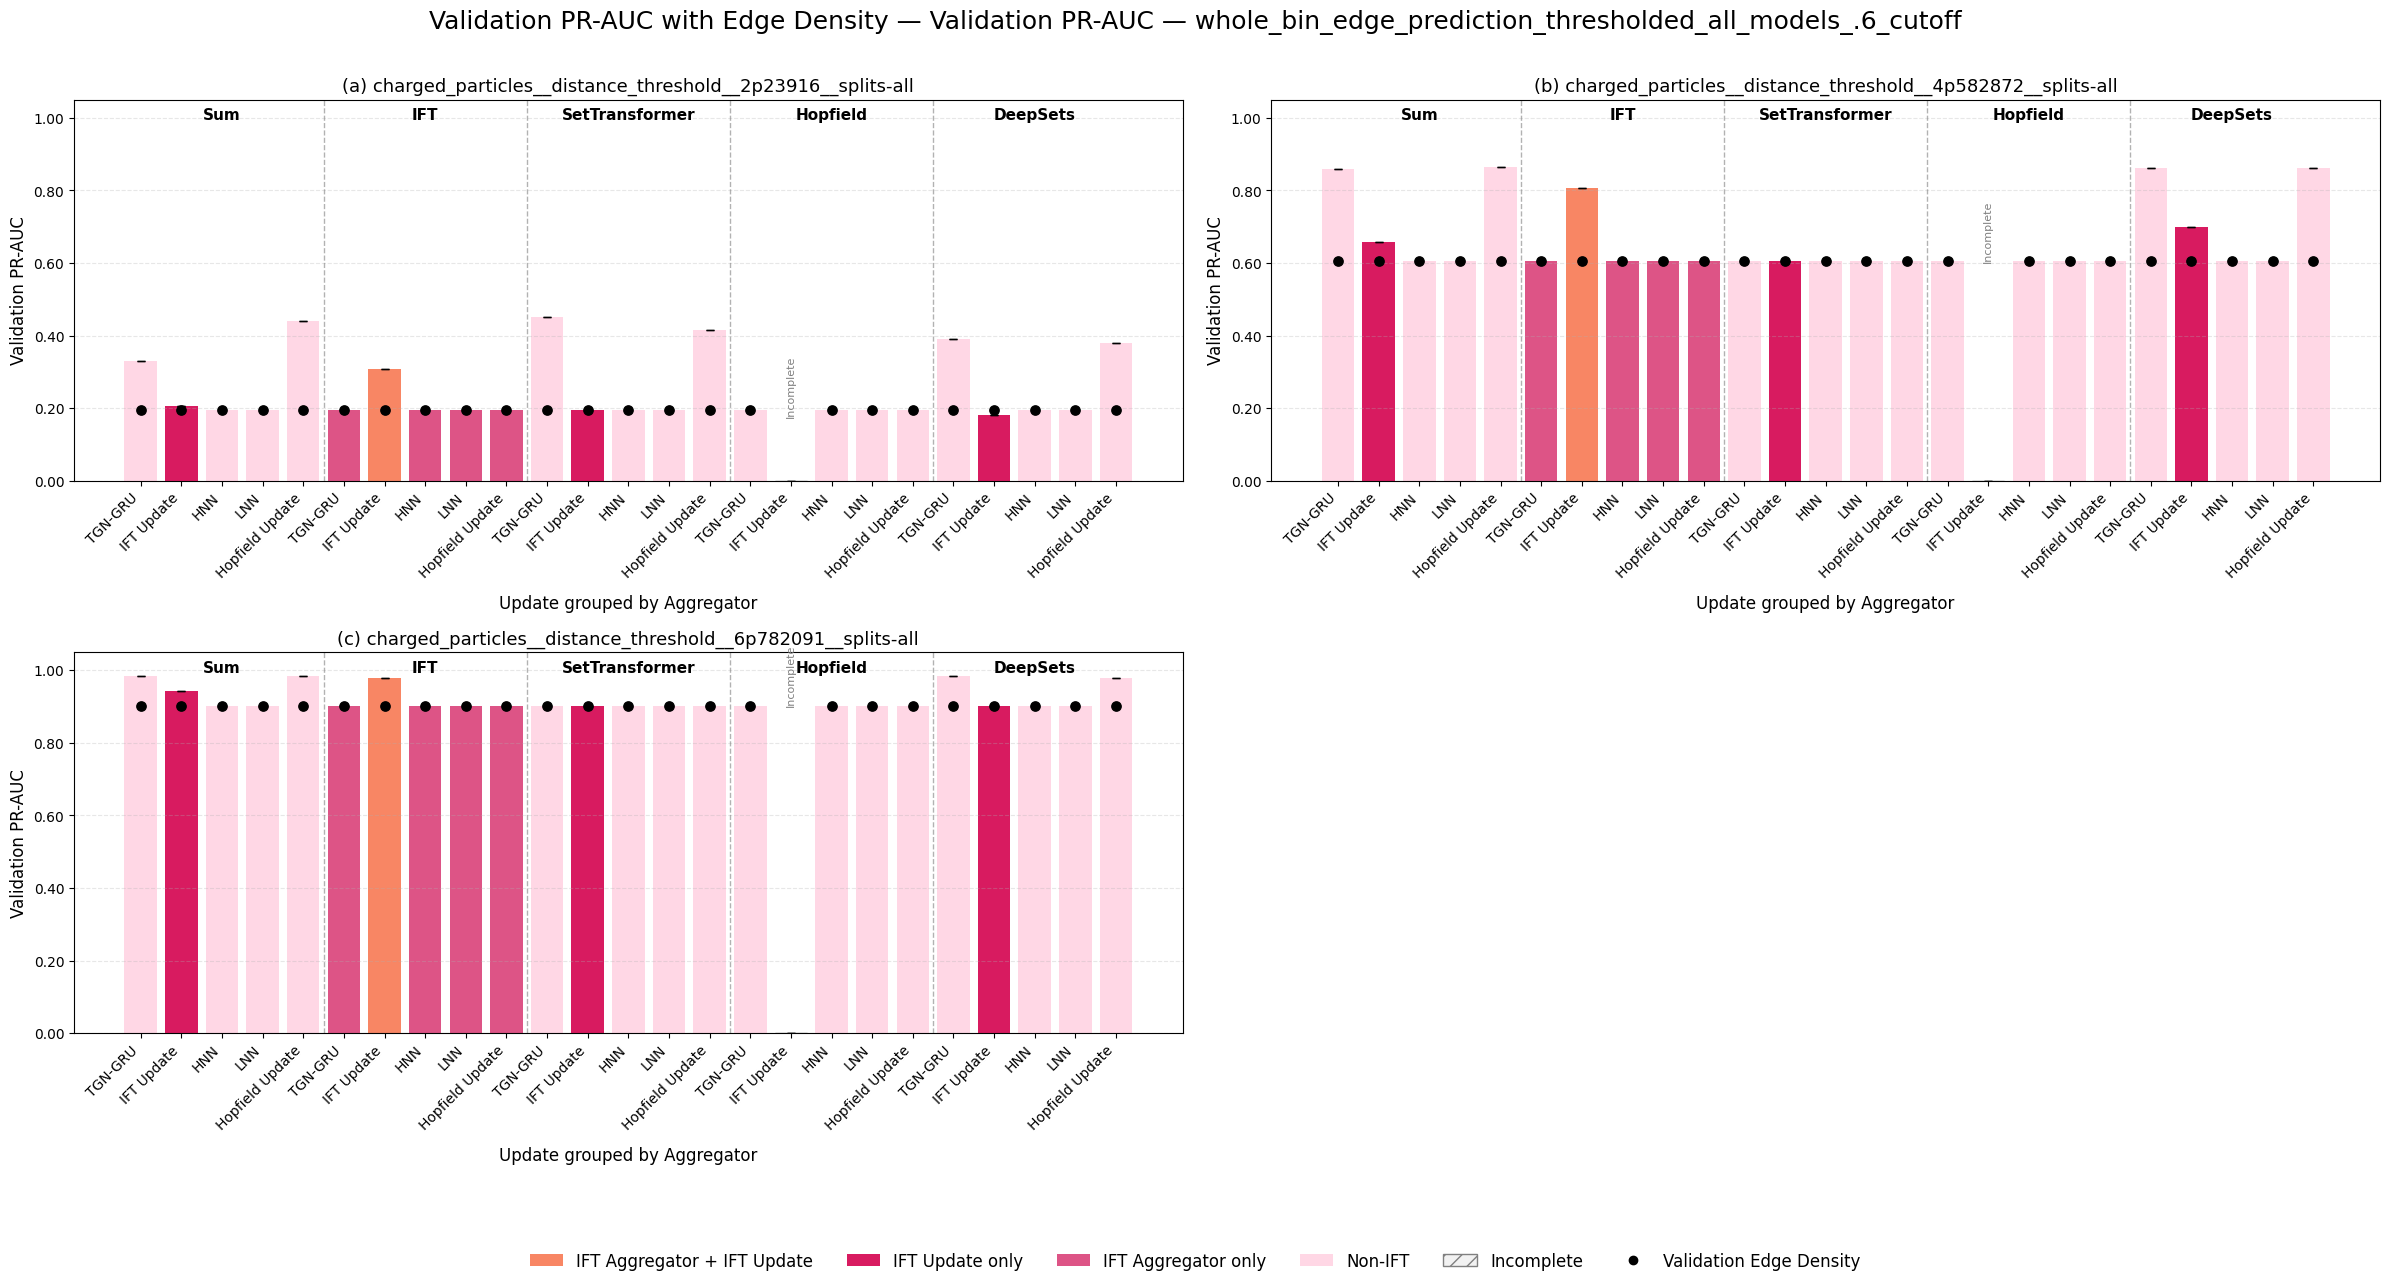

In [ ]:
plot_grouped_metric_with_density(
    summary_df,
    metric_col="val_pr_auc",
    density_col="val_edge_density",
    metric_label="Validation PR-AUC",
    density_label="Validation Edge Density",
    plot_filename="grouped_val_pr_auc_with_density.png",
    title_prefix="Validation PR-AUC with Edge Density",
    ylim=(0, 1.05),
)

saved plot to: plots/grouped_test_pr_auc_with_density.png


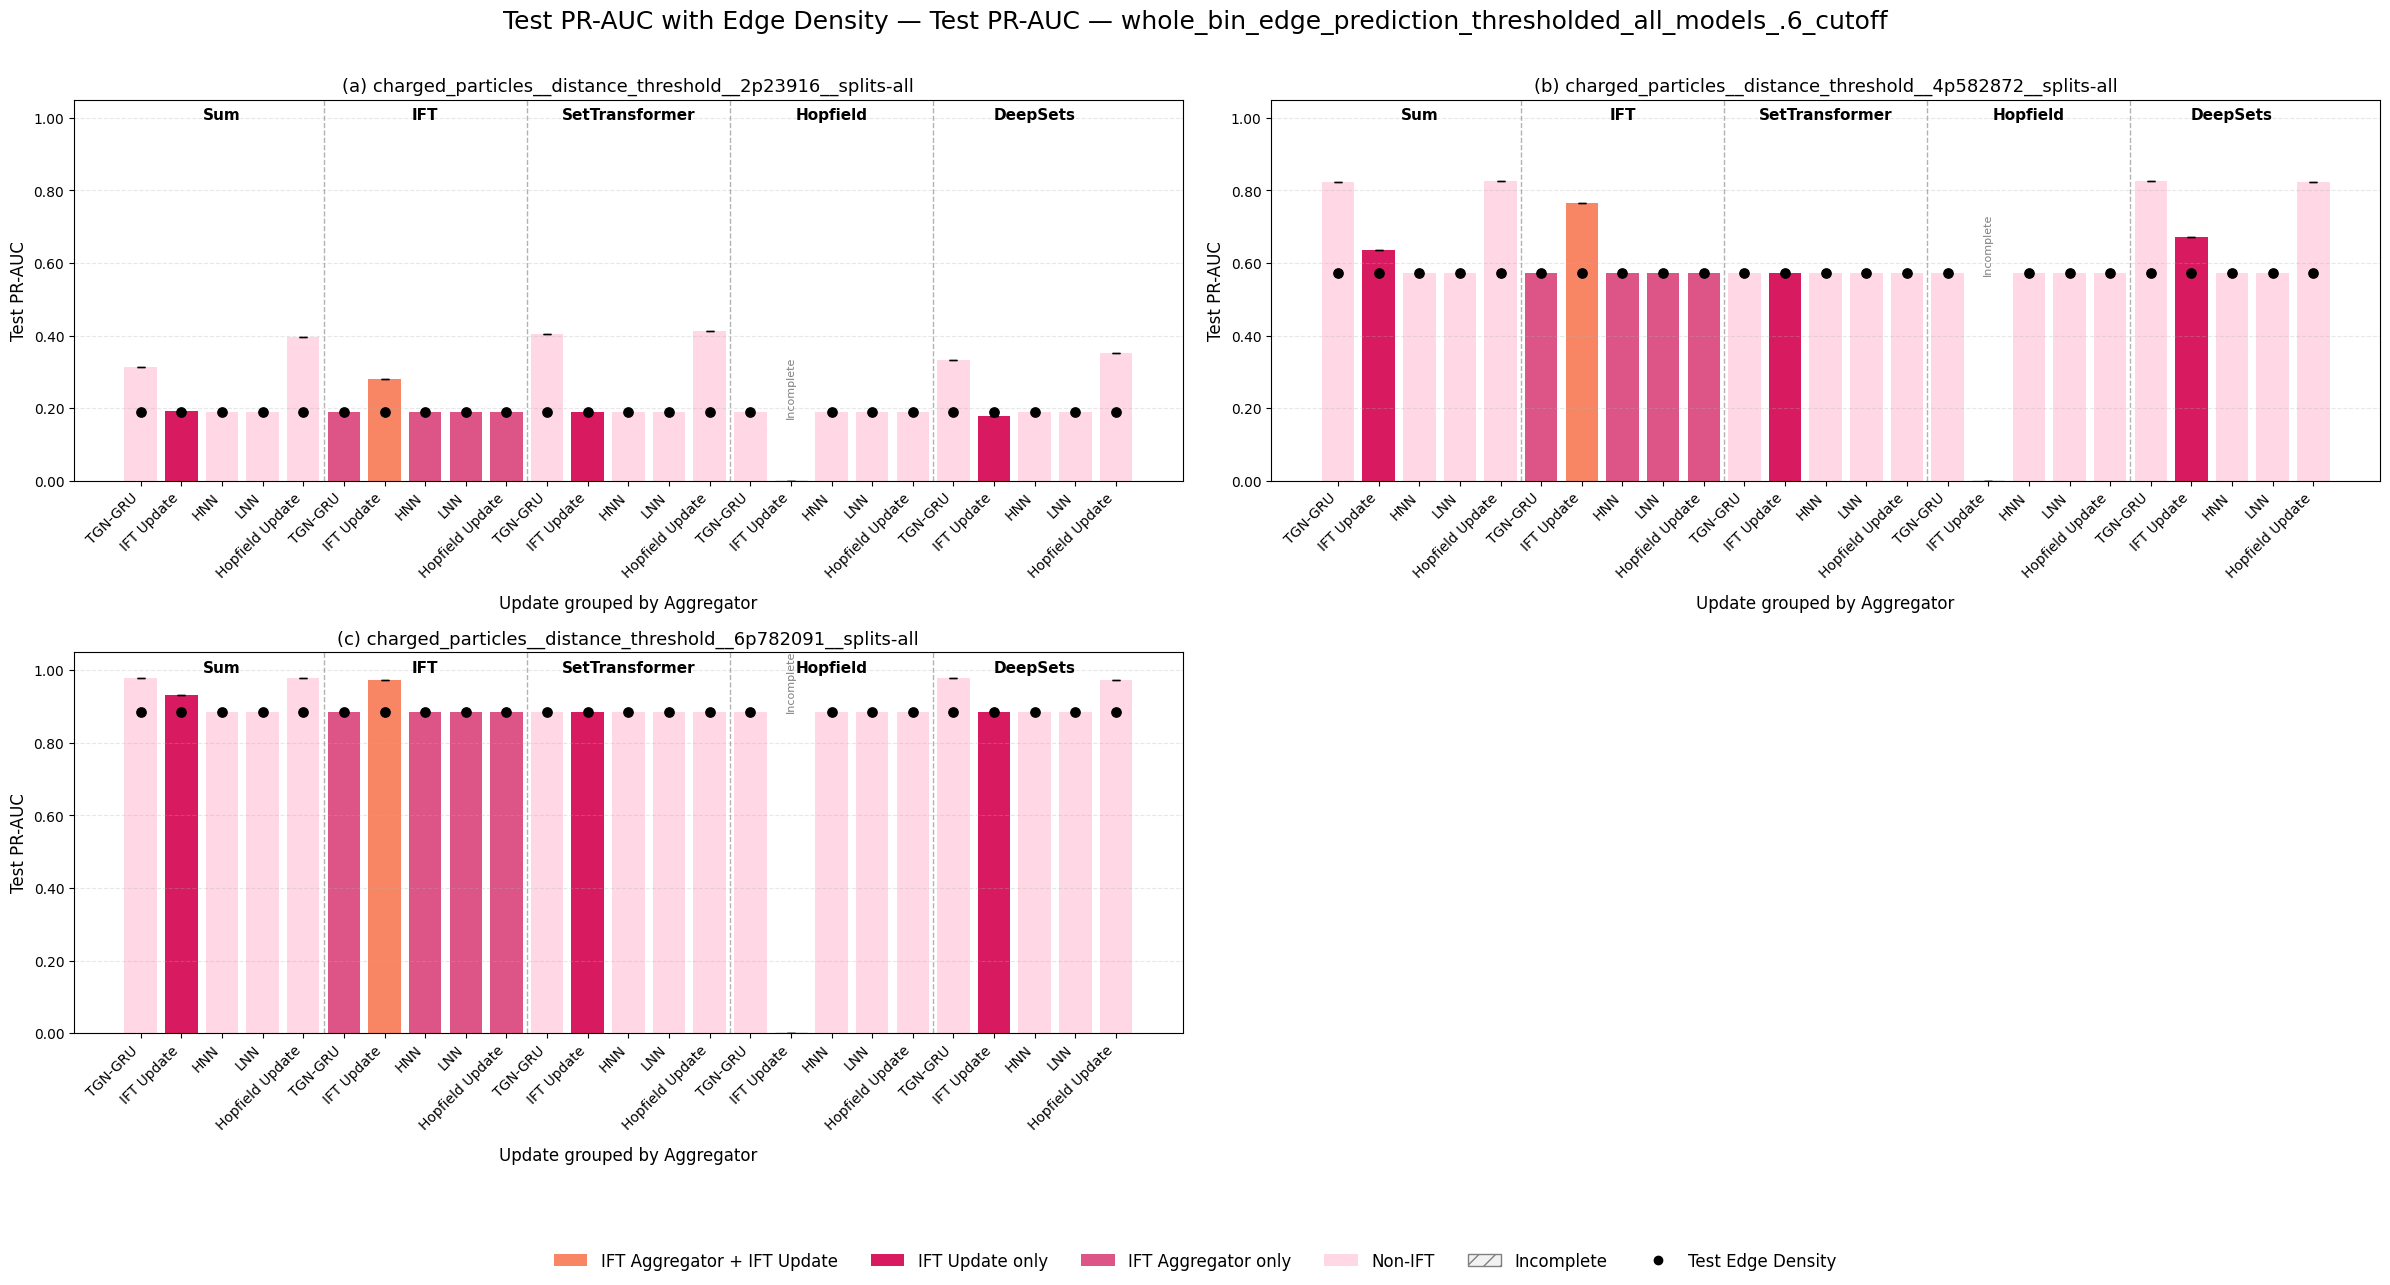

In [ ]:
plot_grouped_metric_with_density(
    summary_df,
    metric_col="test_pr_auc",
    density_col="test_edge_density",
    metric_label="Test PR-AUC",
    density_label="Test Edge Density",
    plot_filename="grouped_test_pr_auc_with_density.png",
    title_prefix="Test PR-AUC with Edge Density",
    ylim=(0, 1.05),
)

saved plot to: plots/grouped_val_roc_auc_with_density.png


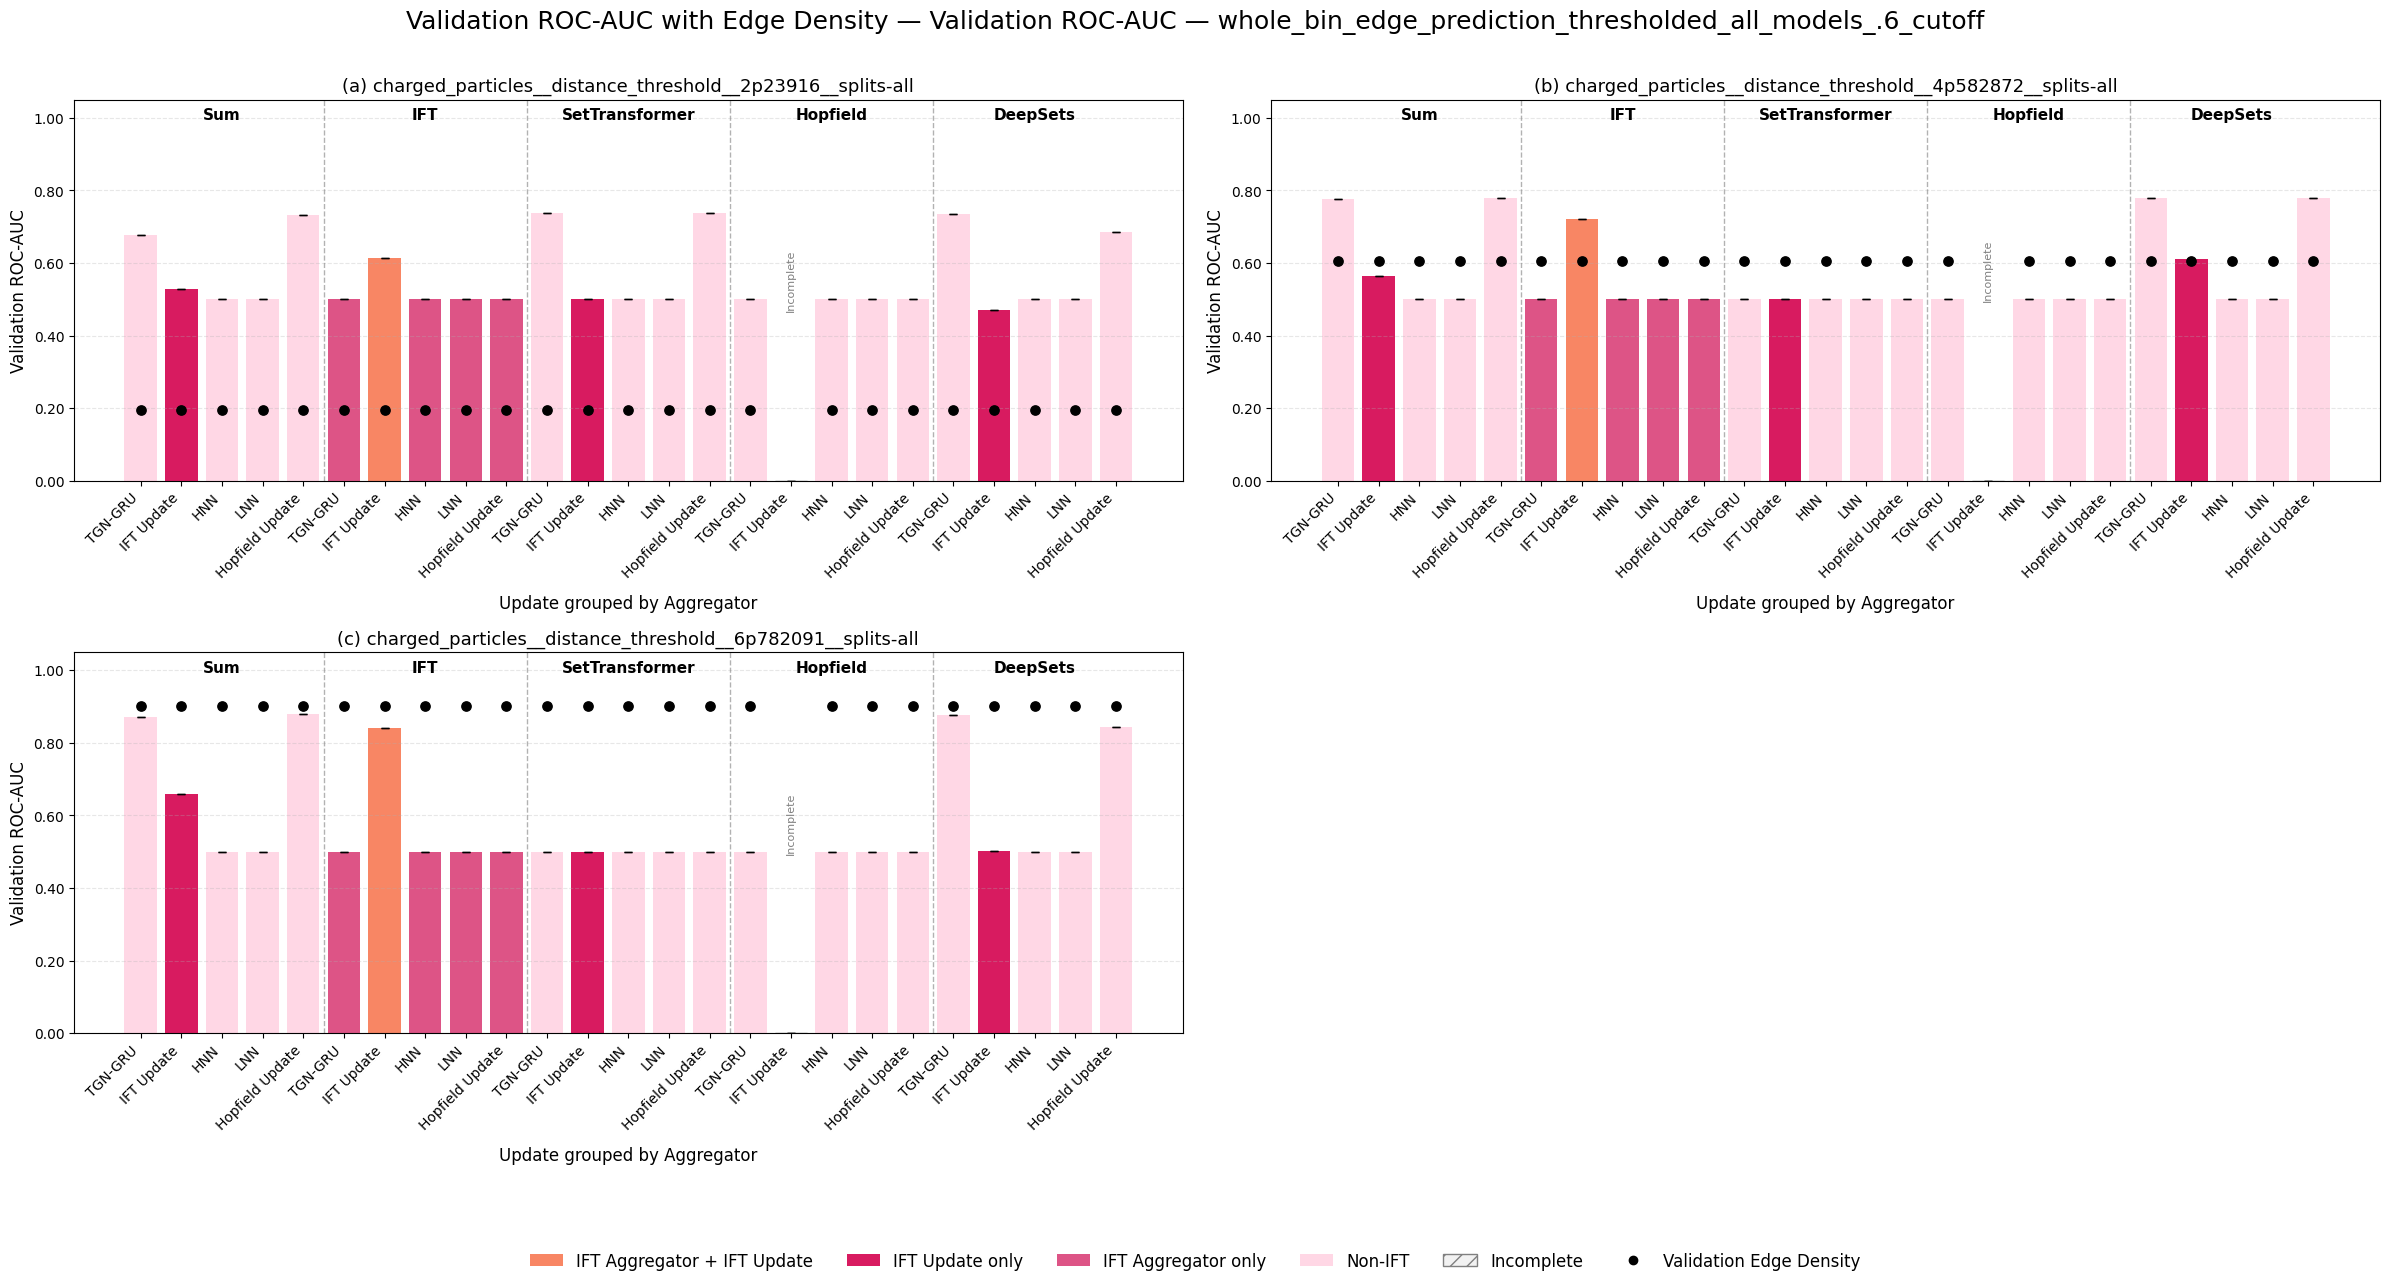

In [ ]:
plot_grouped_metric_with_density(
    summary_df,
    metric_col="val_roc_auc",
    density_col="val_edge_density",
    metric_label="Validation ROC-AUC",
    density_label="Validation Edge Density",
    plot_filename="grouped_val_roc_auc_with_density.png",
    title_prefix="Validation ROC-AUC with Edge Density",
    ylim=(0, 1.05),
)

saved plot to: plots/grouped_val_norm_pr_auc_with_density.png


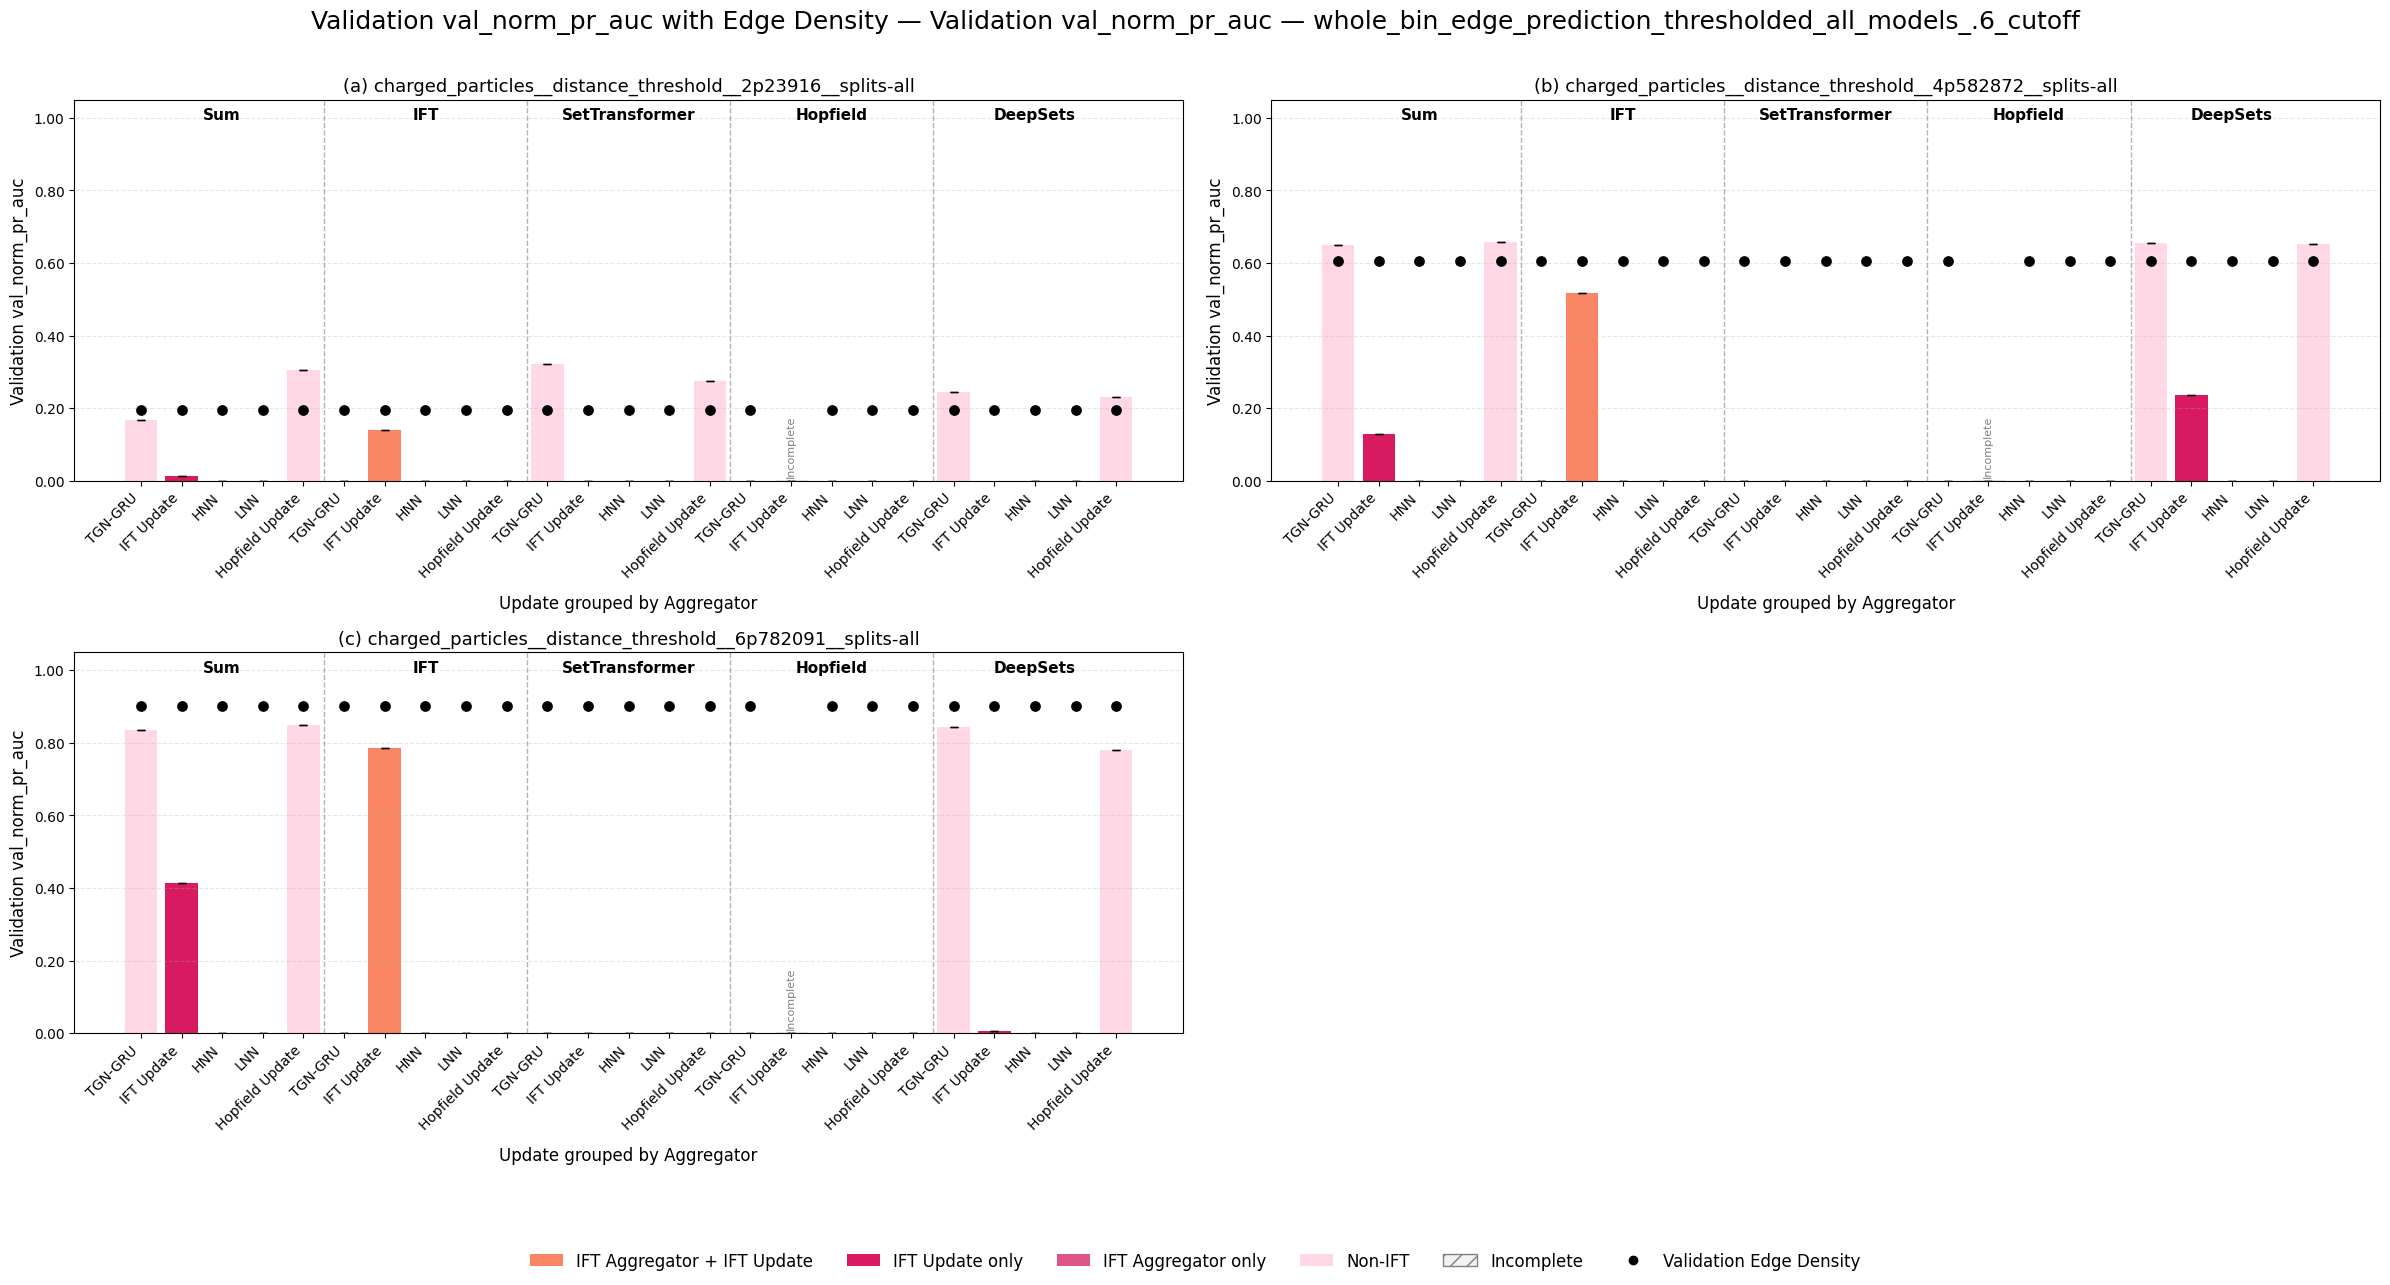

In [ ]:
plot_grouped_metric_with_density(
    summary_df,
    metric_col="val_norm_pr_auc",
    density_col="val_edge_density",
    metric_label="Validation val_norm_pr_auc",
    density_label="Validation Edge Density",
    plot_filename="grouped_val_norm_pr_auc_with_density.png",
    title_prefix="Validation val_norm_pr_auc with Edge Density",
    ylim=(0, 1.05),
)

saved plot to: plots/grouped_val_norm_pr_auc.png


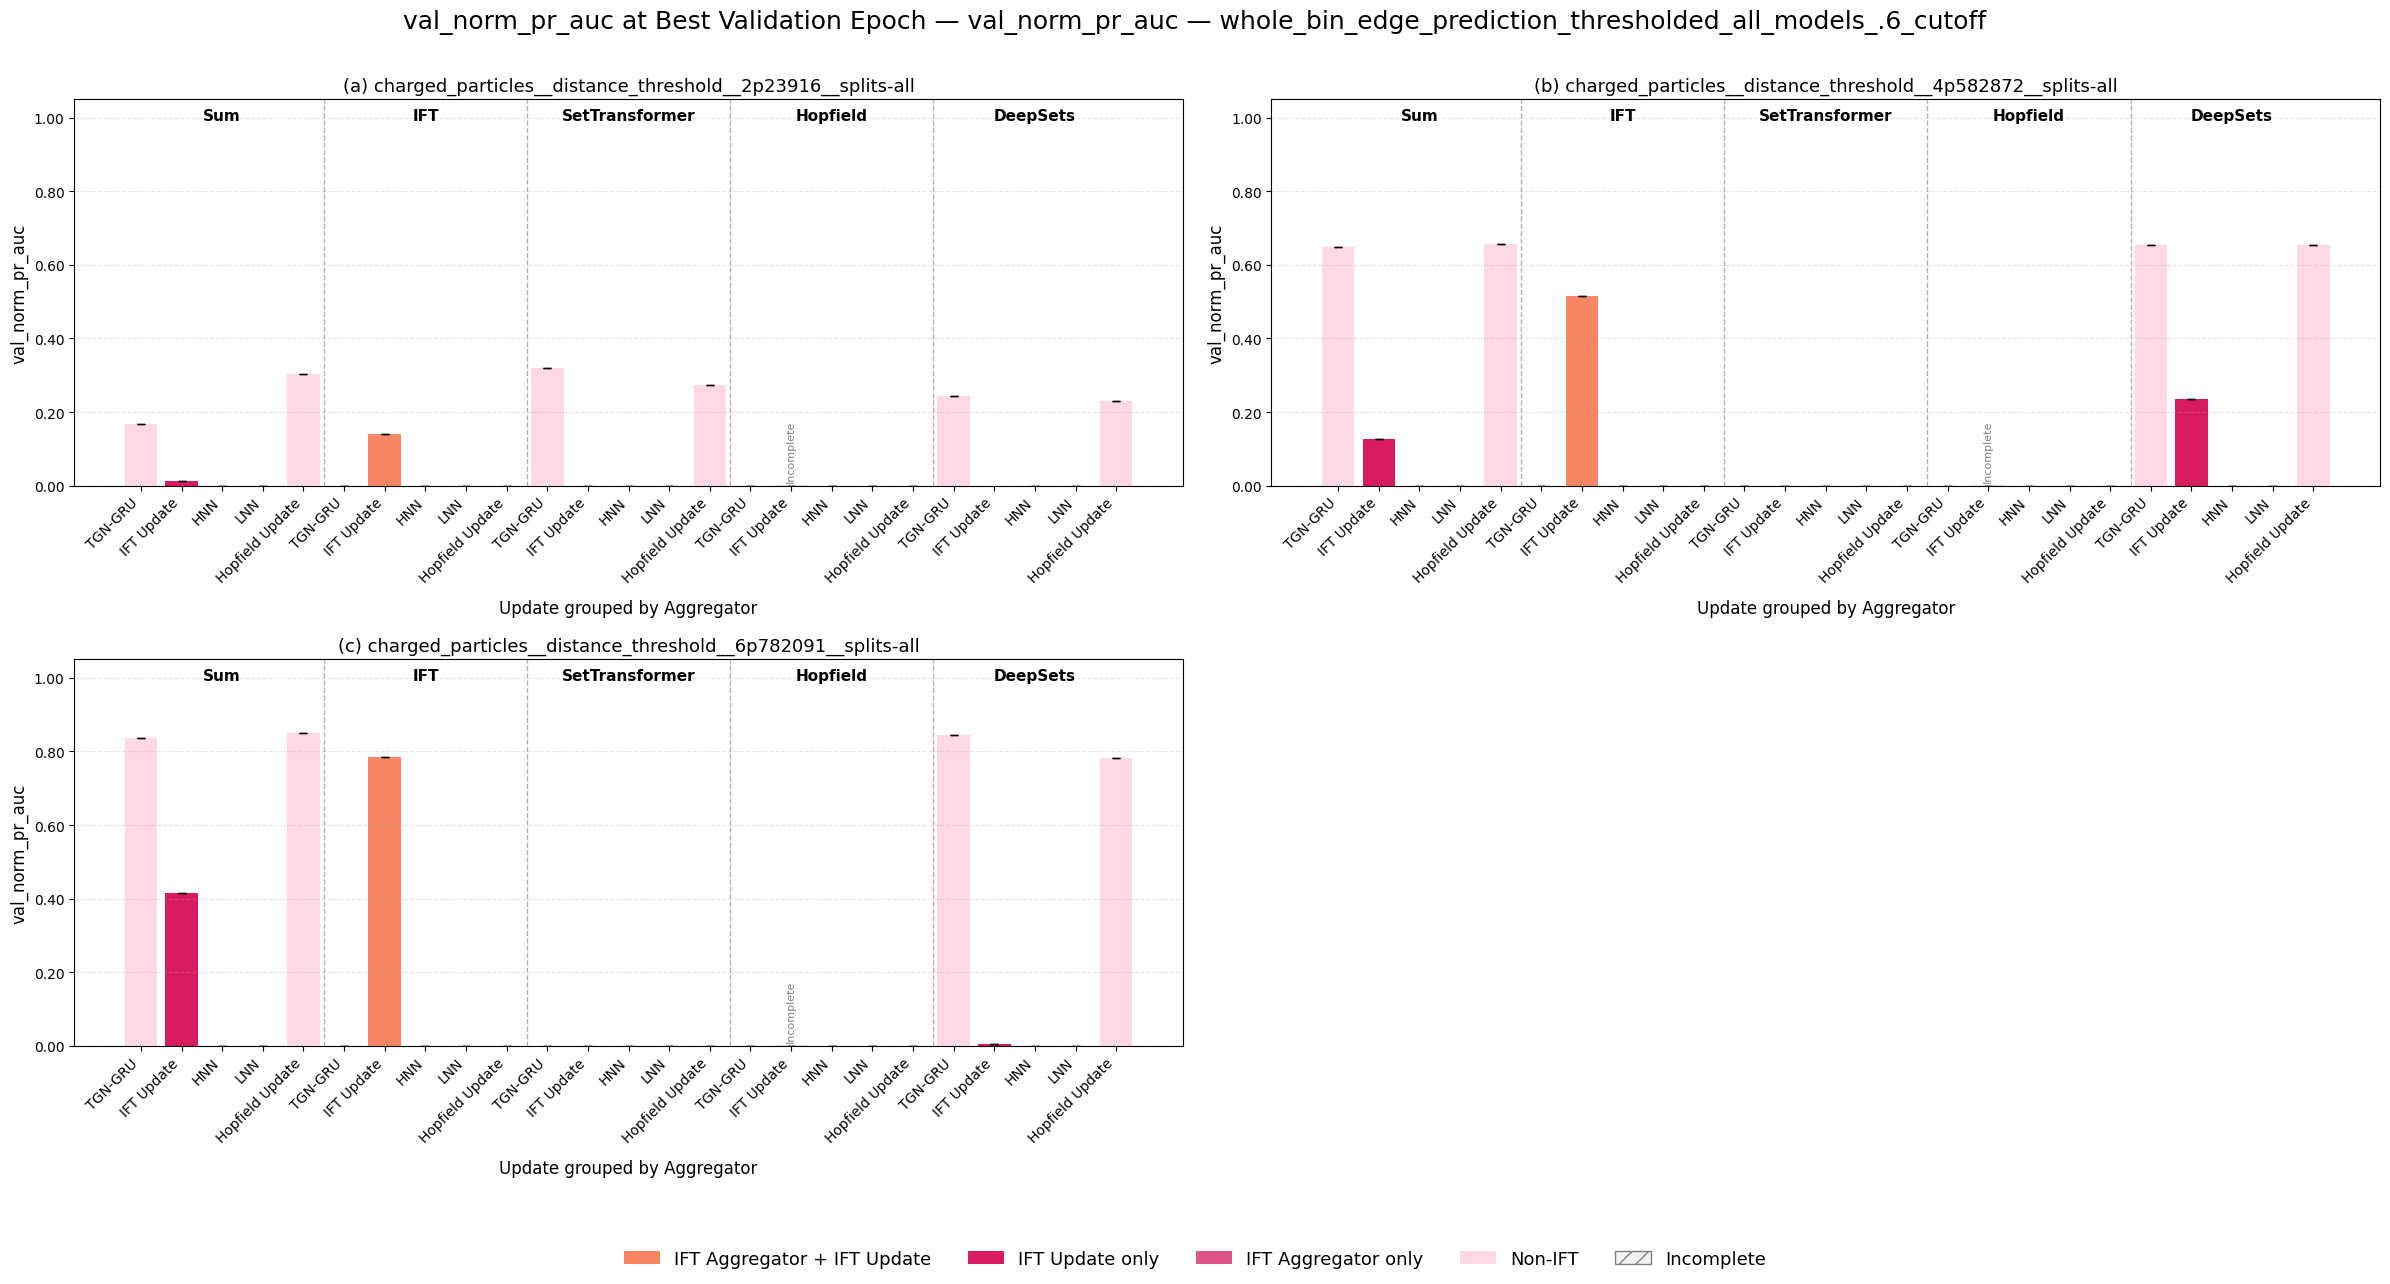

In [ ]:
plot_grouped_metric(
    summary_df,
    metric_col="val_norm_pr_auc",
    metric_label="val_norm_pr_auc",
    plot_filename="grouped_val_norm_pr_auc.png",
    title_prefix="val_norm_pr_auc at Best Validation Epoch",
    ylim=(0, 1.05),
)